***ARUN***


In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)

features_df = pd.read_csv("Features_volatility.csv")
features_df["date"] = pd.to_datetime(features_df["date"])
features_df = features_df.set_index("date")

feature_cols = [
    "global_vol", "vol_slope", "vov",
    "SPY_return", "QQQ_return",
    "SPY_vol_12", "SPY_vol_4", "SPY_momentum_12",
    "VIX", "VIX_change",
    "TREASURY_10Y", "TREASURY_2Y", "yield_spread",
]

print("features_df loaded")
print(features_df[feature_cols].head())
print()
print("Date range:", features_df.index.min(), "to", features_df.index.max())
print("Rows:", len(features_df))


regime_df = pd.read_parquet("regime_labeled_k3.parquet").sort_index()
regime_df["regime_name"] = regime_df["regime_name"].replace({
    "0": "Opportunity",
    "1": "Normal",
    "2": "Stress"
})
print()
print("regime_df loaded")
print(regime_df[["regime", "regime_name"]].head())
print()
print("Regime counts:")
print(regime_df["regime_name"].value_counts(dropna=False))

# Build modeling dataframe
model_df = features_df[feature_cols].copy()
model_df["target"] = regime_df["regime_name"].reindex(model_df.index).shift(-1)
model_df.dropna(inplace=True)

print(f"Modeling rows: {len(model_df):,}")
print(f"Date range: {model_df.index.min().date()} to {model_df.index.max().date()}")
print()
print("Target class counts:")
print(model_df['target'].value_counts())
print()

# Chronological split
TRAIN_END = '2010-12-31'
TEST_START = '2011-01-01'

train = model_df.loc[:TRAIN_END]
test = model_df.loc[TEST_START:]

X_train, y_train = train[feature_cols], train['target']
X_test, y_test = test[feature_cols], test['target']

print(f"Training rows: {len(train):,} ({train.index.min().date()} to {train.index.max().date()})")
print(f"Testing rows:  {len(test):,} ({test.index.min().date()} to {test.index.max().date()})")
print()

for split_name, y in [("Train", y_train), ("Test", y_test)]:
    print(f"{split_name} class distribution:")
    print(y.value_counts(normalize=True).round(3))
    print()

# Scale data only for logistic regression
from sklearn.preprocessing import StandardScaler

sup_scaler = StandardScaler()
X_train_sc = sup_scaler.fit_transform(X_train)
X_test_sc = sup_scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("LOGISTIC REGRESSION - Out-of-sample performance")
print(classification_report(y_test, y_pred_lr, digits=3))
print()

# naive persistence model
persistence_pred = y_test.shift(1).fillna(method="bfill")

print("Persistence baseline accuracy:",
      (persistence_pred == y_test).mean())

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST - Out-of-sample performance")
print(classification_report(y_test, y_pred_rf, digits=3))
print()


# Confusion matrices
class_order = ["change", "no change"]

models_to_plot = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
]


n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, y_pred, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices - Test Set (2011-present)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary metrics
rows = []
for name, y_pred in models_to_plot:
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision (weighted)": round(
            precision_score(y_test, y_pred, average='weighted', zero_division=0), 4
        ),
        "Recall (weighted)": round(
            recall_score(y_test, y_pred, average='weighted', zero_division=0), 4
        ),
    })

summary_df = pd.DataFrame(rows).set_index("Model")
print("Model summary:")
print(summary_df.to_string())
print()

# Feature interpretation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic regression coefficients
ax0 = axes[0]

if len(lr.classes_) == 2:
    # For binary logistic regression, sklearn stores one coefficient vector:
    # class_1 relative to class_0
    coef_s = pd.Series(
        lr.coef_[0],
        index=feature_cols,
        name=f"{lr.classes_[1]} vs {lr.classes_[0]}"
    ).sort_values()

    coef_s.plot(kind="barh", ax=ax0, color="steelblue", alpha=0.8)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title(f"Logistic Regression Coefficients\n({lr.classes_[1]} vs {lr.classes_[0]})")
    ax0.set_xlabel("Coefficient")
else:
    coef_df = pd.DataFrame(lr.coef_, columns=feature_cols, index=lr.classes_)
    colors = ["steelblue", "darkorange", "green", "purple", "red"]

    feature_order = np.argsort(np.abs(coef_df.values).mean(axis=0))
    ordered_features = np.array(feature_cols)[feature_order]

    for i, cls in enumerate(lr.classes_):
        vals = coef_df.loc[cls, ordered_features]
        ax0.barh(
            np.arange(len(ordered_features)) + i * 0.25,
            vals,
            height=0.25,
            color=colors[i % len(colors)],
            alpha=0.8,
            label=cls
        )

    ax0.set_yticks(np.arange(len(ordered_features)) + 0.25)
    ax0.set_yticklabels(ordered_features, fontsize=9)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title("Logistic Regression Coefficients (per class)")
    ax0.legend(fontsize=9)

# Random forest feature importance
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
fi.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title("Random Forest - Feature Importances")
axes[1].set_xlabel("Mean Decrease in Impurity")

plt.suptitle("Feature Interpretation", fontsize=13)
plt.tight_layout()
plt.show()

# Simple lookahead-bias sanity checks
assert (X_train.index < pd.Timestamp(TEST_START)).all()
assert (X_test.index >= pd.Timestamp(TEST_START)).all()
assert model_df.index.equals(model_df.index.sort_values())
assert not X_train.isna().any().any()
assert not X_test.isna().any().any()

features_df loaded
            global_vol  vol_slope       vov  SPY_return  QQQ_return  \
date                                                                  
2004-11-26    0.017904  -0.002760  0.002622    0.007921    0.013702   
2004-12-03    0.017909  -0.006027  0.002257    0.007605    0.023463   
2004-12-10    0.017488  -0.003261  0.002410    0.000671   -0.004984   
2004-12-17    0.016667  -0.002127  0.002522    0.005650   -0.002052   
2004-12-24    0.016023  -0.001375  0.002586    0.011135    0.007347   

            SPY_vol_12  SPY_vol_4  SPY_momentum_12    VIX  VIX_change  \
date                                                                    
2004-11-26    0.017007   0.018439         0.063100  12.78   -0.053333   
2004-12-03    0.016996   0.009352         0.062279  12.96    0.014085   
2004-12-10    0.017046   0.007760         0.057744  12.76   -0.015432   
2004-12-17    0.015872   0.003348         0.079848  11.95   -0.063480   
2004-12-24    0.015417   0.004366         0.0

ValueError: At least one label specified must be in y_true

## \#\# Using Arun's foundation and  updated unsupervised target regime to see results\.

regime labeled sc, added spy lag vix lag, spread lad

In [159]:
## Spencer: Same as above, wanted to test new broken up logic


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)



# Step 1: Load and prepare features
features_df = pd.read_csv("Features_volatility.csv")
features_df["date"] = pd.to_datetime(features_df["date"])
features_df = features_df.sort_values("date").set_index("date")

# Lagged predictors
features_df["SPY_return_lag1"] = features_df["SPY_return"].shift(1)
features_df["SPY_return_lag2"] = features_df["SPY_return"].shift(2)
features_df["VIX_change_lag1"] = features_df["VIX_change"].shift(1)
features_df["yield_spread_lag1"] = features_df["yield_spread"].shift(1)

# Predictive feature set
predict_cols = [
    "SPY_return",
    "QQQ_return",
    "SPY_momentum_12",
    "VIX_change",
    "SPY_vol_4",
    "SPY_vol_12",
    "yield_spread",
    "SPY_return_lag1",
    "SPY_return_lag2",
    "VIX_change_lag1",
    "yield_spread_lag1"
]

print("features_df loaded")
print(features_df[predict_cols].head())
print()
print("Date range:", features_df.index.min(), "to", features_df.index.max())
print("Rows:", len(features_df))


# Step 2: Load regime labels
regime_df = pd.read_parquet("regime_labeled_k_combine.parquet").sort_index()

# Align both datasets on common dates
common_idx = features_df.index.intersection(regime_df.index)
features_df = features_df.loc[common_idx].copy()
regime_df = regime_df.loc[common_idx].copy()


# Step 3: Create current regime name from 3-class labels
regime_df["regime_name"] = regime_df["regime_3class"].map({
    0: "Opportunity",
    1: "Still Good",
    2: "Stress"
})

# Next-period target
regime_df["target_regime"] = regime_df["regime_3class"].shift(-1)

regime_df["target_regime_name"] = regime_df["target_regime"].map({
    0: "Opportunity",
    1: "Still Good",
    2: "Stress"
})

class_order = ["Opportunity", "Still Good", "Stress"]

print()
print("regime_df loaded")
print(
    regime_df[
        ["regime", "regime_3class", "regime_name", "target_regime", "target_regime_name"]
    ].head()
)
print()
print("Current regime counts:")
print(regime_df["regime_name"].value_counts(dropna=False))
print()
print("Target regime counts:")
print(regime_df["target_regime_name"].value_counts(dropna=False))

# Step 4: Build final supervised dataset

model_df = features_df[predict_cols].copy()
model_df["target"] = regime_df["target_regime_name"].reindex(model_df.index)

# Drop rows with missing predictors or target
model_df = model_df.dropna().copy()

print()
print(f"Modeling rows: {len(model_df):,}")
print(f"Date range: {model_df.index.min().date()} to {model_df.index.max().date()}")
print()
print("Target class counts:")
print(model_df["target"].value_counts())
print()


TRAIN_END = "2010-12-31"
TEST_START = "2011-01-01"

train = model_df.loc[:TRAIN_END]
test = model_df.loc[TEST_START:]

X_train, y_train = train[predict_cols], train["target"]
X_test, y_test = test[predict_cols], test["target"]

majority_class = y_train.value_counts().idxmax()

majority_pred = pd.Series(
    [majority_class] * len(y_test),
    index=y_test.index
)

majority_acc = accuracy_score(y_test, majority_pred)

print("Majority baseline accuracy:", round(majority_acc, 4))


print(f"Training rows: {len(train):,} ({train.index.min().date()} to {train.index.max().date()})")
print(f"Testing rows:  {len(test):,} ({test.index.min().date()} to {test.index.max().date()})")
print()

for split_name, y in [("Train", y_train), ("Test", y_test)]:
    print(f"{split_name} class distribution:")
    print(y.value_counts(normalize=True).round(3))
    print()



sup_scaler = StandardScaler()
X_train_sc = sup_scaler.fit_transform(X_train)
X_test_sc = sup_scaler.transform(X_test)



lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight = 'balanced'
)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("LOGISTIC REGRESSION - Out-of-sample performance")
print(classification_report(y_test, y_pred_lr, digits=3))
print()



persistence_pred = y_test.shift(1)
persistence_pred.iloc[0] = y_train.iloc[-1]


persistence_acc = accuracy_score(y_test, persistence_pred)

print("Persistence baseline accuracy:", round(persistence_acc, 4))



rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    class_weight = 'balanced'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST - Out-of-sample performance")
print(classification_report(y_test, y_pred_rf, digits=3))
print()



class_order = ["Opportunity", "Still Good", "Stress"]


models_to_plot = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
]

n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, y_pred, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices - Test Set (2011-present)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



rows = []

# Majority baseline
rows.append({
    "Model": "Majority Baseline",
    "Accuracy": round(accuracy_score(y_test, majority_pred), 4),
    "Precision (weighted)": round(
        precision_score(y_test, majority_pred, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y_test, majority_pred, average="weighted", zero_division=0), 4
    ),
})

# Persistence baseline
rows.append({
    "Model": "Persistence Baseline",
    "Accuracy": round(accuracy_score(y_test, persistence_pred), 4),
    "Precision (weighted)": round(
        precision_score(y_test, persistence_pred, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y_test, persistence_pred, average="weighted", zero_division=0), 4
    ),
})

# ML models
for name, y_pred in models_to_plot:
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision (weighted)": round(
            precision_score(y_test, y_pred, average="weighted", zero_division=0), 4
        ),
        "Recall (weighted)": round(
            recall_score(y_test, y_pred, average="weighted", zero_division=0), 4
        ),
    })

summary_df = pd.DataFrame(rows).set_index("Model")

print("Model summary:")
print(summary_df.to_string())
print()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic regression coefficients
ax0 = axes[0]

if len(lr.classes_) == 2:
    coef_s = pd.Series(
        lr.coef_[0],
        index=predict_cols,
        name=f"{lr.classes_[1]} vs {lr.classes_[0]}"
    ).sort_values()

    coef_s.plot(kind="barh", ax=ax0, color="steelblue", alpha=0.8)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title(f"Logistic Regression Coefficients\n({lr.classes_[1]} vs {lr.classes_[0]})")
    ax0.set_xlabel("Coefficient")
else:
    coef_df = pd.DataFrame(lr.coef_, columns=predict_cols, index=lr.classes_)
    colors = ["steelblue", "darkorange", "green", "purple", "red"]

    feature_order = np.argsort(np.abs(coef_df.values).mean(axis=0))
    ordered_features = np.array(predict_cols)[feature_order]

    for i, cls in enumerate(lr.classes_):
        vals = coef_df.loc[cls, ordered_features]
        ax0.barh(
            np.arange(len(ordered_features)) + i * 0.25,
            vals,
            height=0.25,
            color=colors[i % len(colors)],
            alpha=0.8,
            label=cls
        )

    ax0.set_yticks(np.arange(len(ordered_features)) + 0.25)
    ax0.set_yticklabels(ordered_features, fontsize=9)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title("Logistic Regression Coefficients (per class)")
    ax0.legend(fontsize=9)

# Random forest feature importance
fi = pd.Series(rf.feature_importances_, index=predict_cols).sort_values()
fi.plot(kind="barh", ax=axes[1], color="steelblue", alpha=0.8)
axes[1].set_title("Random Forest - Feature Importances")
axes[1].set_xlabel("Mean Decrease in Impurity")

plt.suptitle("Feature Interpretation", fontsize=13)
plt.tight_layout()
plt.show()



assert (X_train.index < pd.Timestamp(TEST_START)).all()
assert (X_test.index >= pd.Timestamp(TEST_START)).all()
assert model_df.index.equals(model_df.index.sort_values())
assert not X_train.isna().any().any()
assert not X_test.isna().any().any()

features_df loaded
            SPY_return  QQQ_return  SPY_momentum_12  VIX_change  SPY_vol_4  \
date                                                                         
2004-11-26    0.007921    0.013702         0.063100   -0.053333   0.018439   
2004-12-03    0.007605    0.023463         0.062279    0.014085   0.009352   
2004-12-10    0.000671   -0.004984         0.057744   -0.015432   0.007760   
2004-12-17    0.005650   -0.002052         0.079848   -0.063480   0.003348   
2004-12-24    0.011135    0.007347         0.070833   -0.060251   0.004366   

            SPY_vol_12  yield_spread  SPY_return_lag1  SPY_return_lag2  \
date                                                                     
2004-11-26    0.017007          1.21              NaN              NaN   
2004-12-03    0.016996          1.33         0.007921              NaN   
2004-12-10    0.017046          1.21         0.007605         0.007921   
2004-12-17    0.015872          1.18         0.000671         0.

In [161]:
plt.figure(figsize=(14,4))
plt.scatter(regime_df.index, regime_df["regime"], s=4)
plt.title("Market Regimes Over Time")
plt.show()

In [163]:
pd.crosstab(
    regime_df["regime"],
    regime_df["regime_3class"],
    normalize="index"
)

regime_3class,0,1,2
regime,,,
0.0,1.0,0.0,0.0
1.0,0.0,0.0,1.0
2.0,0.0,1.0,0.0


In [165]:
baseline_pred = regime_df.loc[y_test.index, "regime_name"]
accuracy_score(y_test, baseline_pred)

accuracy_score(y_test, baseline_pred)

0.9418758256274768

In [167]:
## Exporting supervised predictions for backtest.

# Crate prediction dataframe using test period only
pred_df = pd.DataFrame(index=X_test.index.copy())

# Actual next-period regime
pred_df["actual_regime"] = y_test

# Model predictions
pred_df["pred_lr"] = y_pred_lr
pred_df["pred_rf"] = y_pred_rf

# Prediction probabilities
if hasattr(lr, "predict_proba"):
    lr_proba = lr.predict_proba(X_test_sc)
    for i, cls in enumerate(lr.classes_):
        pred_df[f"lr_proba_{cls}"] = lr_proba[:, i]

if hasattr(rf, "predict_proba"):
    rf_proba = rf.predict_proba(X_test)
    for i, cls in enumerate(rf.classes_):
        pred_df[f"rf_proba_{cls}"] = rf_proba[:, i]

# Add current observed regime from unsupervised labels
pred_df["current_regime"] = regime_df.loc[pred_df.index, "regime_name"]

# Add current numeric 3-class label
pred_df["current_regime_num"] = regime_df.loc[pred_df.index, "regime_3class"]

# Add target numeric label
pred_df["target_regime_num"] = regime_df.loc[pred_df.index, "target_regime"]

# Optional: keep raw original cluster too
if "regime" in regime_df.columns:
    pred_df["raw_cluster"] = regime_df.loc[pred_df.index, "regime"]

# Sort
pred_df = pred_df.sort_index()

print("Export dataframe preview:")
print(pred_df.head())
print()
print("Export dataframe shape:", pred_df.shape)
print("Date range:", pred_df.index.min().date(), "to", pred_df.index.max().date())

# Export
pred_df.to_parquet("combined_supervised_predictions.parquet")

print("\nSaved: combined_supervised_predictions.parquet")

Export dataframe preview:
           actual_regime      pred_lr      pred_rf  lr_proba_Opportunity  \
2011-01-07   Opportunity  Opportunity  Opportunity              0.748960   
2011-01-14   Opportunity  Opportunity  Opportunity              0.684142   
2011-01-21   Opportunity   Still Good  Opportunity              0.430214   
2011-01-28   Opportunity   Still Good  Opportunity              0.433598   
2011-02-04   Opportunity   Still Good  Opportunity              0.376378   

            lr_proba_Still Good  lr_proba_Stress  rf_proba_Opportunity  \
2011-01-07             0.250913         0.000127              0.783472   
2011-01-14             0.315746         0.000112              0.825315   
2011-01-21             0.569371         0.000415              0.532629   
2011-01-28             0.565403         0.000999              0.529714   
2011-02-04             0.623266         0.000356              0.580861   

            rf_proba_Still Good  rf_proba_Stress current_regime  \
2011-

In [168]:
plt.figure(figsize=(14,4))
plt.plot(regime_df.index, regime_df["VIX"], alpha=0.6)

plt.scatter(
    regime_df.index,
    regime_df["VIX"],
    c=regime_df["regime"],
    cmap="coolwarm",
    s=8
)

plt.title("Market Volatility and Regime Classification")
plt.show()

In [170]:
import seaborn as sns
transition = pd.crosstab(
    regime_df["regime"],
    regime_df["regime_3class"],
    normalize="index"
)

plt.figure(figsize=(4,3))
sns.heatmap(transition, annot=True, cmap="Blues")
plt.title("Regime Transition Probabilities")
plt.show()

In [172]:
#regime_df

# PHUC'S PART FROM ARUN AND SPENCER RUN \(2 LAYER\)


Modeling rows: 1,049
Date range: 2004-12-31 to 2026-02-13

Target class counts:
target
no change    991
change        58
Name: count, dtype: int64

Majority baseline accuracy: 0.9222
Training rows: 544 (2004-12-31 to 2015-12-25)
Validation rows:  246 (2016-01-08 to 2020-12-25)
Testing rows:  257 (2021-01-08 to 2026-02-13)

Train class distribution:
target
no change    0.956
change       0.044
Name: proportion, dtype: float64

Validation class distribution:
target
no change    0.947
change       0.053
Name: proportion, dtype: float64

Test class distribution:
target
no change    0.922
change       0.078
Name: proportion, dtype: float64

threshold: 0.05 f1: 0.055 chg: 0.244
threshold: 0.060000000000000005 f1: 0.063 chg: 0.203
threshold: 0.07 f1: 0.089 chg: 0.13
threshold: 0.08000000000000002 f1: 0.053 chg: 0.102
threshold: 0.09000000000000001 f1: 0.059 chg: 0.085
threshold: 0.1 f1: 0.074 chg: 0.057
threshold: 0.11000000000000001 f1: 0.087 chg: 0.041
threshold: 0.12000000000000001 f1: 0.

ValueError: At least one label specified must be in y_true

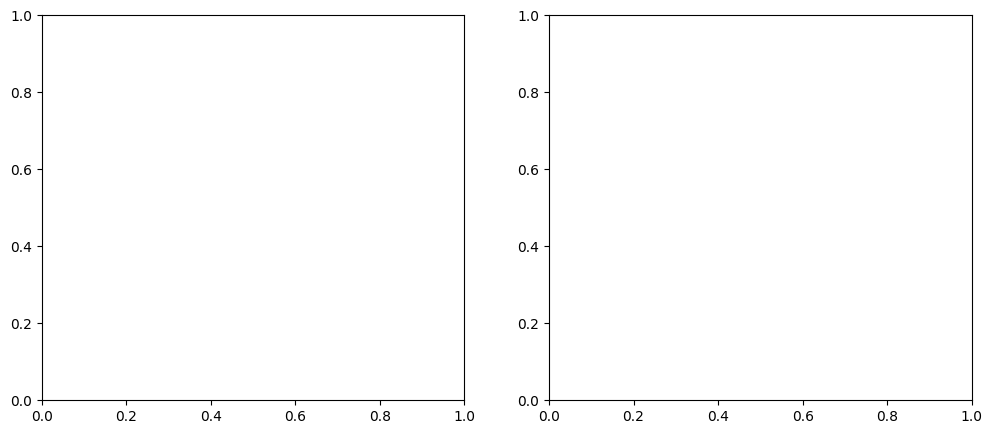

In [1]:
#Add validation set to pick model
#Create 2 layer. 1st layer predict % regime will change


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)


# Step 1: Load and prepare features
features_df = pd.read_csv("Features_volatility.csv")
features_df["date"] = pd.to_datetime(features_df["date"])
features_df = features_df.sort_values("date").set_index("date")

# Lagged predictors
for i in range(1, 6):
    features_df[f"SPY_return_lag{i}"] = features_df["SPY_return"].shift(i)
    features_df[f"VIX_change_lag{i}"] = features_df["VIX_change"].shift(i)
    features_df[f"yield_spread_lag{i}"] = features_df["yield_spread"].shift(i)

# Predictive feature set
predict_cols = [
    "SPY_return",
    "QQQ_return",
    "SPY_momentum_12",
    "VIX_change",
    "SPY_vol_4",
    "SPY_vol_12",
    "yield_spread",
    "SPY_return_lag1",
    "SPY_return_lag2",
    "SPY_return_lag3",
    "SPY_return_lag4",
    "SPY_return_lag5",
    "VIX_change_lag1",
    "VIX_change_lag2",
    "VIX_change_lag3",
    "VIX_change_lag4",
    "VIX_change_lag5",
    "yield_spread_lag1",
    "yield_spread_lag2",
    "yield_spread_lag3",
    "yield_spread_lag4",
    "yield_spread_lag5"
]

# Step 2: Load regime labels
regime_df = pd.read_parquet("regime_labeled_k_combine.parquet").sort_index()

# Align both datasets on common dates
common_idx = features_df.index.intersection(regime_df.index)
features_df = features_df.loc[common_idx].copy()
regime_df = regime_df.loc[common_idx].copy()


# Step 3: Create current regime name from 3-class labels
regime_df["regime_name"] = regime_df["regime_3class"].map({
    0: "Low_Vol",
    1: "Mid_Vol",
    2: "High_Vol"
})

# Next-period target
regime_df["target_regime"] = regime_df["regime_3class"].shift(-1)

regime_df["target_regime_name"] = regime_df["target_regime"].map({
    0: "Low_Vol",
    1: "Mid_Vol",
    2: "High_Vol"
})


regime_df["target_change"] = np.where(regime_df["target_regime_name"] != regime_df["regime_name"],'change','no change')
regime_df.loc[regime_df["target_regime_name"].isna(), "target_change"] = np.nan

class_order = ["change", "no change"]


# Step 4: Build final supervised dataset

model_df = features_df[predict_cols].copy()
current_regime = regime_df["regime_name"].reindex(model_df.index)
next_regime = regime_df["target_regime_name"].reindex(model_df.index)
target = regime_df["target_change"].reindex(model_df.index)
model_df["current_regime"] = current_regime
model_df["next_regime"] = next_regime
model_df["target"] = target

# Drop rows with missing predictors or target
model_df = model_df.dropna().copy()

print()
print(f"Modeling rows: {len(model_df):,}")
print(f"Date range: {model_df.index.min().date()} to {model_df.index.max().date()}")
print()
print("Target class counts:")
print(model_df["target"].value_counts())
print()

TRAIN_END = "2015-12-31"
vald = "2020-12-31"

train = model_df.loc[:TRAIN_END]
val = model_df.loc[TRAIN_END:vald].iloc[1:]
test = model_df.loc[vald:].iloc[1:]

X_train, y_train = train[predict_cols], train["target"]
X_val, y_val = val[predict_cols], val["target"]
X_test, y_test = test[predict_cols], test["target"]

majority_class = y_train.value_counts().idxmax()

majority_pred = pd.Series([majority_class] * len(y_test), index=y_test.index)

majority_acc = accuracy_score(y_test, majority_pred)

print("Majority baseline accuracy:", round(majority_acc, 4))


print(f"Training rows: {len(train):,} ({train.index.min().date()} to {train.index.max().date()})")
print(f"Validation rows:  {len(val):,} ({val.index.min().date()} to {val.index.max().date()})")
print(f"Testing rows:  {len(test):,} ({test.index.min().date()} to {test.index.max().date()})")
print()

for split_name, y in [("Train", y_train), ("Validation", y_val),("Test", y_test)]:
    print(f"{split_name} class distribution:")
    print(y.value_counts(normalize=True).round(3))
    print()



sup_scaler = StandardScaler()
X_train_sc = sup_scaler.fit_transform(X_train)
X_test_sc = sup_scaler.transform(X_test)
X_val_sc = sup_scaler.transform(X_val)


lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
cid = list(lr.classes_).index("change")
pvl = lr.predict_proba(X_val_sc)[:, cid]
pts = lr.predict_proba(X_test_sc)[:, cid]
ths = np.arange(0.05,0.6,0.01)
bst = 0.5
bsc = -1
for i in ths:
    yvl = np.where(pvl >= i, "change", "no change")
    f1 = f1_score(y_val, yvl, pos_label="change")
    rte = (yvl == "change").mean()
    print("threshold:", i, "f1:", round(f1, 3), "chg:", round(rte, 3))
    if rte > 0 and f1 > bsc:
        bsc = f1
        bst = i

print()
print("best threshold:", bst)

y_pred_lr_val = np.where(pvl >= bst, "change", "no change")
y_pred_lr = np.where(pts >= bst, "change", "no change")

print("LOGISTIC REGRESSION - Validation performance")
print(classification_report(y_val, y_pred_lr_val, digits=3))
print()
print("LOGISTIC REGRESSION - Test performance")
print(classification_report(y_test, y_pred_lr, digits=3))
print()


per_pred = pd.Series("no change", index=y_test.index)
persistence_acc = accuracy_score(y_test, per_pred)

print("Persistence baseline accuracy:", round(persistence_acc, 4))



rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1, class_weight = 'balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf_val = rf.predict(X_val)

print("RANDOM FOREST - Validation performance")
print(classification_report(y_val, y_pred_rf_val, digits=3))
print()
print("RANDOM FOREST - Test performance")
print(classification_report(y_test, y_pred_rf, digits=3))
print()

class_order = ["Opportunity", "Still Good", "Stress"]

models_to_plot = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
]

n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, y_pred, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices - Test Set (2021-present)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



rows = []

# Majority baseline
rows.append({
    "Model": "Majority Baseline",
    "Accuracy": round(accuracy_score(y_test, majority_pred), 4),
    "Precision (weighted)": round(
        precision_score(y_test, majority_pred, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y_test, majority_pred, average="weighted", zero_division=0), 4
    ),
})

# Persistence baseline
rows.append({
    "Model": "Persistence Baseline",
    "Accuracy": round(accuracy_score(y_test, per_pred), 4),
    "Precision (weighted)": round(
        precision_score(y_test, per_pred, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y_test, per_pred, average="weighted", zero_division=0), 4
    ),
})

# ML models
for name, y_pred in models_to_plot:
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision (weighted)": round(
            precision_score(y_test, y_pred, average="weighted", zero_division=0), 4
        ),
        "Recall (weighted)": round(
            recall_score(y_test, y_pred, average="weighted", zero_division=0), 4
        ),
    })

summary_df = pd.DataFrame(rows).set_index("Model")

print("Model summary:")
print(summary_df.to_string())
print()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic regression coefficients
ax0 = axes[0]

if len(lr.classes_) == 2:
    coef_s = pd.Series(
        lr.coef_[0],
        index=predict_cols,
        name=f"{lr.classes_[1]} vs {lr.classes_[0]}"
    ).sort_values()

    coef_s.plot(kind="barh", ax=ax0, color="steelblue", alpha=0.8)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title(f"Logistic Regression Coefficients\n({lr.classes_[1]} vs {lr.classes_[0]})")
    ax0.set_xlabel("Coefficient")
else:
    coef_df = pd.DataFrame(lr.coef_, columns=predict_cols, index=lr.classes_)
    colors = ["steelblue", "darkorange", "green", "purple", "red"]

    feature_order = np.argsort(np.abs(coef_df.values).mean(axis=0))
    ordered_features = np.array(predict_cols)[feature_order]

    for i, cls in enumerate(lr.classes_):
        vals = coef_df.loc[cls, ordered_features]
        ax0.barh(
            np.arange(len(ordered_features)) + i * 0.25,
            vals,
            height=0.25,
            color=colors[i % len(colors)],
            alpha=0.8,
            label=cls
        )

    ax0.set_yticks(np.arange(len(ordered_features)) + 0.25)
    ax0.set_yticklabels(ordered_features, fontsize=9)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title("Logistic Regression Coefficients (per class)")
    ax0.legend(fontsize=9)

# Random forest feature importance
fi = pd.Series(rf.feature_importances_, index=predict_cols).sort_values()
fi.plot(kind="barh", ax=axes[1], color="steelblue", alpha=0.8)
axes[1].set_title("Random Forest - Feature Importances")
axes[1].set_xlabel("Mean Decrease in Impurity")

plt.suptitle("Feature Interpretation", fontsize=13)
plt.tight_layout()
plt.show()

In [145]:
#Layer 2: if change, what is the new regime?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)


# Layer 2: if change, what is the new regime?

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

predict_cols2 = [
    "SPY_return",
    "QQQ_return",
    "VIX_change",
    "SPY_vol_4",
    "yield_spread",
    "SPY_return_lag1",
    "SPY_return_lag2",
    "VIX_change_lag1",
    "VIX_change_lag2",
    "yield_spread_lag1",
    "yield_spread_lag2"
]

cdf = model_df[model_df["target"] == "change"].copy()
sc2 = StandardScaler()

l2t = cdf.loc[:TRAIN_END].copy()
l2v = cdf.loc[(cdf.index > TRAIN_END) & (cdf.index <= vald)].copy()
l2tt = cdf.loc[cdf.index > vald].copy()

tt = pd.crosstab(l2t["current_regime"], l2t["next_regime"])
likely = tt.idxmax(axis=1)
fn = l2t["next_regime"].value_counts().idxmax()

basev = l2v["current_regime"].map(likely).fillna(fn)
baset = l2tt["current_regime"].map(likely).fillna(fn)

x2t = l2t[predict_cols2].copy()
dtr = pd.get_dummies(l2t["current_regime"], prefix="cur")
x2t = pd.concat([x2t, dtr], axis=1)
x2v = l2v[predict_cols2].copy()
dva = pd.get_dummies(l2v["current_regime"], prefix="cur")
x2v = pd.concat([x2v, dva], axis=1)
x2tt = l2tt[predict_cols2].copy()
dte = pd.get_dummies(l2tt["current_regime"], prefix="cur")
x2tt = pd.concat([x2tt, dte], axis=1)
x2v = x2v.reindex(columns=x2t.columns, fill_value=0)
x2tt = x2tt.reindex(columns=x2t.columns, fill_value=0)

y2t = l2t["next_regime"]
y2v = l2v["next_regime"]
y2tt = l2tt["next_regime"]

x2t_sc = x2t.copy()
x2v_sc = x2v.copy()
x2tt_sc = x2tt.copy()

x2t_sc[predict_cols2] = sc2.fit_transform(x2t[predict_cols2])
x2v_sc[predict_cols2] = sc2.transform(x2v[predict_cols2])
x2tt_sc[predict_cols2] = sc2.transform(x2tt[predict_cols2])

lr2 = LogisticRegression(max_iter=1000,random_state=42,class_weight="balanced")

lr2.fit(x2t_sc, y2t)

y2_pred_val = lr2.predict(x2v_sc)
y2_pred_test = lr2.predict(x2tt_sc)

print("LAYER 2 LOGISTIC REGRESSION - Validation performance")
print(classification_report(y2v, y2_pred_val, digits=3, zero_division=0))
print()
print("LAYER 2 LOGISTIC REGRESSION - Test performance")
print(classification_report(y2tt, y2_pred_test, digits=3, zero_division=0))
print()

print("LAYER 2 CONDITIONAL BASELINE - Validation performance")
print(classification_report(y2v, basev, digits=3, zero_division=0))
print()
print("LAYER 2 CONDITIONAL BASELINE - Test performance")
print(classification_report(y2tt, baset, digits=3, zero_division=0))
print()

rows2 = []

rows2.append({
    "Model": "Conditional Baseline",
    "Accuracy": round(accuracy_score(y2tt, baset), 4),
    "Precision (weighted)": round(
        precision_score(y2tt, baset, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y2tt, baset, average="weighted", zero_division=0), 4
    ),
})

rows2.append({
    "Model": "Logistic Regression",
    "Accuracy": round(accuracy_score(y2tt, y2_pred_test), 4),
    "Precision (weighted)": round(
        precision_score(y2tt, y2_pred_test, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y2tt, y2_pred_test, average="weighted", zero_division=0), 4
    ),
})

summary2_df = pd.DataFrame(rows2).set_index("Model")

print("Layer 2 model summary:")
print(summary2_df.to_string())
print()

LAYER 2 LOGISTIC REGRESSION - Validation performance
              precision    recall  f1-score   support

    High_Vol      0.500     1.000     0.667         1
     Low_Vol      0.833     0.833     0.833         6
     Mid_Vol      1.000     0.857     0.923         7

    accuracy                          0.857        14
   macro avg      0.778     0.897     0.808        14
weighted avg      0.893     0.857     0.866        14


LAYER 2 LOGISTIC REGRESSION - Test performance
              precision    recall  f1-score   support

    High_Vol      0.000     0.000     0.000         0
     Low_Vol      1.000     0.800     0.889        10
     Mid_Vol      1.000     1.000     1.000        10

    accuracy                          0.900        20
   macro avg      0.667     0.600     0.630        20
weighted avg      1.000     0.900     0.944        20


LAYER 2 CONDITIONAL BASELINE - Validation performance
              precision    recall  f1-score   support

    High_Vol      0.000    

In [157]:
#combine both layer

reg_cols = ["Low_Vol", "Mid_Vol", "High_Vol"]


xv_all = val[predict_cols2].copy()
dva_all = pd.get_dummies(val["current_regime"], prefix="cur")
xv_all = pd.concat([xv_all, dva_all], axis=1)

xt_all = test[predict_cols2].copy()
dte_all = pd.get_dummies(test["current_regime"], prefix="cur")
xt_all = pd.concat([xt_all, dte_all], axis=1)

xv_all = xv_all.reindex(columns=x2t.columns, fill_value=0)
xt_all = xt_all.reindex(columns=x2t.columns, fill_value=0)

xv_all_sc = xv_all.copy()
xt_all_sc = xt_all.copy()

xv_all_sc[predict_cols2] = sc2.transform(xv_all[predict_cols2])
xt_all_sc[predict_cols2] = sc2.transform(xt_all[predict_cols2])


l2_all_val = pd.Series(lr2.predict(xv_all_sc), index=val.index)
l2_all_test = pd.Series(lr2.predict(xt_all_sc), index=test.index)

b2_all_val = val["current_regime"].map(likely).fillna(fn)
b2_all_test = test["current_regime"].map(likely).fillna(fn)

l1_val = pd.Series(y_pred_lr_val, index=val.index)
l1_test = pd.Series(y_pred_lr, index=test.index)

final_val = val["current_regime"].copy()
final_test = test["current_regime"].copy()

final_val[l1_val == "change"] = l2_all_val[l1_val == "change"]
final_test[l1_test == "change"] = l2_all_test[l1_test == "change"]

final_base_val = val["current_regime"].copy()
final_base_test = test["current_regime"].copy()

final_base_val[l1_val == "change"] = b2_all_val[l1_val == "change"]
final_base_test[l1_test == "change"] = b2_all_test[l1_test == "change"]

yv_reg = val["next_regime"]
yt_reg = test["next_regime"]

print("FULL 2-LAYER MODEL - Validation performance")
print(classification_report(yv_reg, final_val, labels=reg_cols, digits=3, zero_division=0))
print()
print("FULL 2-LAYER MODEL - Test performance")
print(classification_report(yt_reg, final_test, labels=reg_cols, digits=3, zero_division=0))
print()

print("FULL 2-LAYER BASELINE - Validation performance")
print(classification_report(yv_reg, final_base_val, labels=reg_cols, digits=3, zero_division=0))
print()
print("FULL 2-LAYER BASELINE - Test performance")
print(classification_report(yt_reg, final_base_test, labels=reg_cols, digits=3, zero_division=0))
print()

print("FULL PERSISTENCE BASELINE - Validation performance")
print(classification_report(yv_reg, val["current_regime"], labels=reg_cols, digits=3, zero_division=0))
print()
print("FULL PERSISTENCE BASELINE - Test performance")
print(classification_report(yt_reg, test["current_regime"], labels=reg_cols, digits=3, zero_division=0))
print()

rows3 = []

rows3.append({
    "Model": "Persistence Baseline",
    "Accuracy": round(accuracy_score(yt_reg, test["current_regime"]), 4),
    "Precision (weighted)": round(
        precision_score(yt_reg, test["current_regime"], average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(yt_reg, test["current_regime"], average="weighted", zero_division=0), 4
    ),
})

rows3.append({
    "Model": "2-Layer Baseline",
    "Accuracy": round(accuracy_score(yt_reg, final_base_test), 4),
    "Precision (weighted)": round(
        precision_score(yt_reg, final_base_test, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(yt_reg, final_base_test, average="weighted", zero_division=0), 4
    ),
})

rows3.append({
    "Model": "2-Layer Model",
    "Accuracy": round(accuracy_score(yt_reg, final_test), 4),
    "Precision (weighted)": round(
        precision_score(yt_reg, final_test, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(yt_reg, final_test, average="weighted", zero_division=0), 4
    ),
})

summary3_df = pd.DataFrame(rows3).set_index("Model")

print("Full model summary:")
print(summary3_df.to_string())
print()


rows4 = []
for i in ["Low_Vol", "Mid_Vol", "High_Vol"]:
    rows4.append({"Regime": i,
        "real label": int((yt_reg == i).sum()),
        "persistence": int((test["current_regime"] == i).sum()),
        "baseline": int((final_base_test == i).sum()),
        "2L model": int((final_test == i).sum()),})
tab4 = pd.DataFrame(rows4).set_index("Regime")
print("TEST COUNTS")
print(tab4.to_string())
print()

rows5 = []
for i in ["Low_Vol", "Mid_Vol", "High_Vol"]:
    rows5.append({"Regime": i,
        "real label": int((yv_reg == i).sum()),
        "persistence": int((val["current_regime"] == i).sum()),
        "baseline": int((final_base_val == i).sum()),
        "2L model": int((final_val == i).sum()),})
tab5 = pd.DataFrame(rows5).set_index("Regime")
print("VAL COUNTS")
print(tab5.to_string())
print()


FULL 2-LAYER MODEL - Validation performance
              precision    recall  f1-score   support

     Low_Vol      0.978     0.946     0.962       185
     Mid_Vol      0.774     0.837     0.804        49
    High_Vol      0.714     0.833     0.769        12

    accuracy                          0.919       246
   macro avg      0.822     0.872     0.845       246
weighted avg      0.924     0.919     0.921       246


FULL 2-LAYER MODEL - Test performance
              precision    recall  f1-score   support

     Low_Vol      0.938     0.938     0.938       195
     Mid_Vol      0.803     0.790     0.797        62
    High_Vol      0.000     0.000     0.000         0

    accuracy                          0.903       257
   macro avg      0.581     0.576     0.578       257
weighted avg      0.906     0.903     0.904       257


FULL 2-LAYER BASELINE - Validation performance
              precision    recall  f1-score   support

     Low_Vol      0.962     0.946     0.954       18

In [151]:
x = test.copy()
x["actual_next_regime"] = yt_reg
x["persist_pred"] = test["current_regime"]
x["2l_base_pred"] = final_base_test
x["2l_pred"] = final_test
x["l1_pred"] = l1_test
x.to_parquet("test_2layer_labels.parquet")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=059a5e93-4459-411b-9a58-2a578fd7a892' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>